In [41]:
from pathlib import Path
import pandas as pd
import numpy as np

In [42]:
cwd = Path.cwd().resolve()
data_dir = cwd / "food_data"
if not data_dir.exists():
    data_dir = cwd
    
raw = pd.read_csv(data_dir / "food_knapsack_data.csv")

In [43]:
raw.columns.tolist()

['fdc_id',
 'description',
 'food_category_id',
 'food_category_description',
 'Nitrogen (G)',
 'Protein (G)',
 'Total lipid (fat) (G)',
 'Carbohydrate, by difference (G)',
 'Ash (G)',
 'Energy (KCAL)',
 'Starch (G)',
 'Sucrose (G)',
 'Glucose (G)',
 'Fructose (G)',
 'Lactose (G)',
 'Maltose (G)',
 'Specific Gravity (SP_GR)',
 'Citric acid (MG)',
 'Malic acid (MG)',
 'Oxalic acid (MG)',
 'Pyruvic acid (MG)',
 'Quinic acid (MG)',
 'Carbohydrate, by summation (G)',
 'Water (G)',
 'Energy (kJ)',
 'Sugars, Total (G)',
 'Resistant starch (G)',
 'Galactose (G)',
 'Raffinose (G)',
 'Stachyose (G)',
 'Fiber, total dietary (G)',
 'Fiber, soluble (G)',
 'Fiber, insoluble (G)',
 'Total fat (NLEA) (G)',
 'Calcium, Ca (MG)',
 'Iron, Fe (MG)',
 'Magnesium, Mg (MG)',
 'Phosphorus, P (MG)',
 'Potassium, K (MG)',
 'Sodium, Na (MG)',
 'Sulfur, S (MG)',
 'Zinc, Zn (MG)',
 'Cobalt, Co (UG)',
 'Copper, Cu (MG)',
 'Iodine, I (UG)',
 'Manganese, Mn (MG)',
 'Molybdenum, Mo (UG)',
 'Selenium, Se (UG)',
 'Retin

In [44]:
selected_obj = raw[['Protein (G)', 'Total lipid (fat) (G)', 'Carbohydrate, by difference (G)', 'Sodium, Na (MG)', 'Fiber, total dietary (G)']]
selected_obj = selected_obj.dropna(axis=0, how='any')
selected_obj_arr = selected_obj.to_numpy()
print(selected_obj_arr.shape)

(157, 5)


In [45]:
# correlation structure
corr_matrix = np.corrcoef(selected_obj_arr, rowvar=False)
print(corr_matrix)

[[ 1.          0.72208764  0.4415563  -0.02236387  0.55323854]
 [ 0.72208764  1.         -0.02375531  0.05073091  0.35307666]
 [ 0.4415563  -0.02375531  1.         -0.15009102  0.42645321]
 [-0.02236387  0.05073091 -0.15009102  1.         -0.03260071]
 [ 0.55323854  0.35307666  0.42645321 -0.03260071  1.        ]]


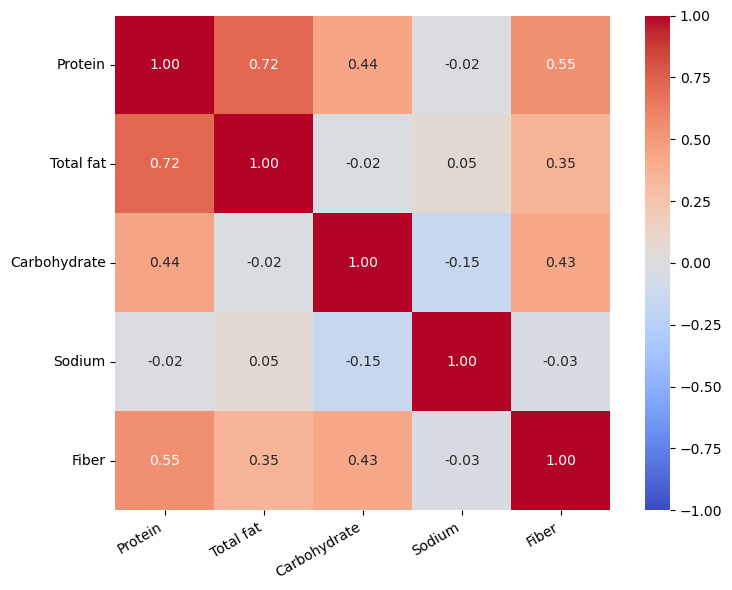

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = [
    "Protein",
    "Total fat",
    "Carbohydrate",
    "Sodium",
    "Fiber",
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
# generate example item list 
# randomly sample from the whole selected_obj
sample_n = 60
random_seed = 525
nutrient_cols = selected_obj.columns.tolist()
meta_cols = ["description", "food_category_description"]
selected_obj_df = raw.loc[selected_obj.index, meta_cols + nutrient_cols].copy()
items = selected_obj_df.sample(n=sample_n, random_state=random_seed).reset_index(drop=True)
print(items.shape)
display(items.head(20))

_items_path = data_dir / "example_items.csv"
items.to_csv(_items_path, index=False)
print(f"Saved: {_items_path.resolve()}")

(60, 7)


,description,food_category_description,Protein (G),Total lipid (fat) (G),"Carbohydrate, by difference (G)","Sodium, Na (MG)","Fiber, total dietary (G)"
0,"Plantains, ripe, raw",Fruits and Fruit Juices,1.156250,0.8933,30.952150,0.0000,2.1250
1,"Sorghum grain, white, pearled, unenriched, dry...",Cereal Grains and Pasta,10.250000,3.2650,74.872000,0.0000,3.9160
2,"Nuts, walnuts, English, halves, raw",Nut and Seed Products,14.564400,69.7400,10.909600,0.0000,5.2100
3,"Mushroom, beech",Vegetables and Vegetable Products,2.180000,0.4494,6.759300,0.8913,3.1390
4,"Rice, brown, long grain, unenriched, raw",Cereal Grains and Pasta,7.253050,3.3060,76.687950,0.0000,3.0210
5,"Mushroom, pioppini",Vegetables and Vegetable Products,3.500000,0.2400,5.763700,0.0000,2.7530
6,"Turnips, raw",Vegetables and Vegetable Products,0.953125,0.1188,7.274975,12.8000,1.9150
7,"Nuts, pecans, halves, raw",Nut and Seed Products,9.958700,73.2800,12.699300,0.0000,5.7930
8,"Peaches, yellow, raw",Fruits and Fruit Juices,0.910000,0.2700,10.100000,13.0000,1.5000
9,"Tomatoes, whole, canned, solids and liquids, w...",Vegetables and Vegetable Products,0.867500,0.2063,4.287400,111.5000,0.8725


Saved: /home/tailai/multiobjective/food_data/example_items.csv


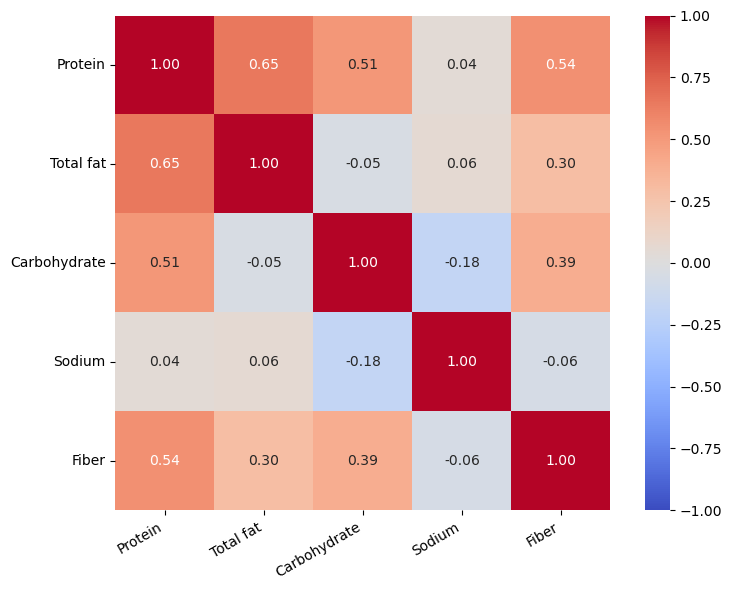

In [61]:
numeric_items = items.select_dtypes(include="number")
items_arr = numeric_items.to_numpy()
corr_matrix = np.corrcoef(items_arr, rowvar=False)

labels = [
    "Protein",
    "Total fat",
    "Carbohydrate",
    "Sodium",
    "Fiber",
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# generate example item list (10 categories, 6 food items per category)
category_ids = [11, 9, 1, 20, 16, 15]
items_per_category = 10
random_seed = 525

nutrient_cols = selected_obj.columns.tolist()
meta_cols = ["fdc_id", "description", "food_category_id", "food_category_description"]

selected_obj_df = raw.loc[selected_obj.index, meta_cols + nutrient_cols].copy()
selected_obj_df = selected_obj_df[selected_obj_df["food_category_id"].isin(category_ids)]

# make sure each requested category has enough items to sample without replacement
category_counts = selected_obj_df["food_category_id"].value_counts()
insufficient = [cid for cid in category_ids if category_counts.get(cid, 0) < items_per_category]
if insufficient:
    raise ValueError(f"Not enough items in categories: {insufficient}")

example_food_item_list = (
    selected_obj_df.groupby("food_category_id", group_keys=False)
    .apply(lambda g: g.sample(n=items_per_category, random_state=random_seed))
    .sort_values(["food_category_id", "description"])
    .reset_index(drop=True)
)

print(example_food_item_list.shape)  # expected: (60, number_of_columns)
example_food_item_list.head(20)